In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/cleaned_used_cars.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (61056, 15)


,name,year,fuel,transmission,registration_location,color,assembly,body_type,price_pkr,mileage_km,engine_cc,battery_kwh,feature_count,brand,model
0,Suzuki Alto VXL AGS 2022,2022,Petrol,Automatic,Islamabad,Solid White,Local,Hatchback,2390000.0,120000.0,660.0,NaN,10,Suzuki,Alto
1,Honda N Box Custom GL 2022,2022,Petrol,Automatic,Islamabad,White,Imported,Hatchback,3340000.0,37110.0,658.0,NaN,20,Honda,N
2,Honda Civic EX 1995,1995,LPG,Manual,Karachi,Black,Local,Sedan,630000.0,786.0,1500.0,NaN,8,Honda,Civic
3,Toyota Corolla GLi Automatic 1.6 VVTi 2012,2012,Petrol,Automatic,Lahore,Medium Silver,Imported,Sedan,3325000.0,133000.0,1600.0,NaN,9,Toyota,Corolla
4,Toyota Corolla Hatchback 1998,1998,Petrol,Automatic,Punjab,Black,Local,Unknown,1645000.0,125225.0,1600.0,NaN,15,Toyota,Corolla


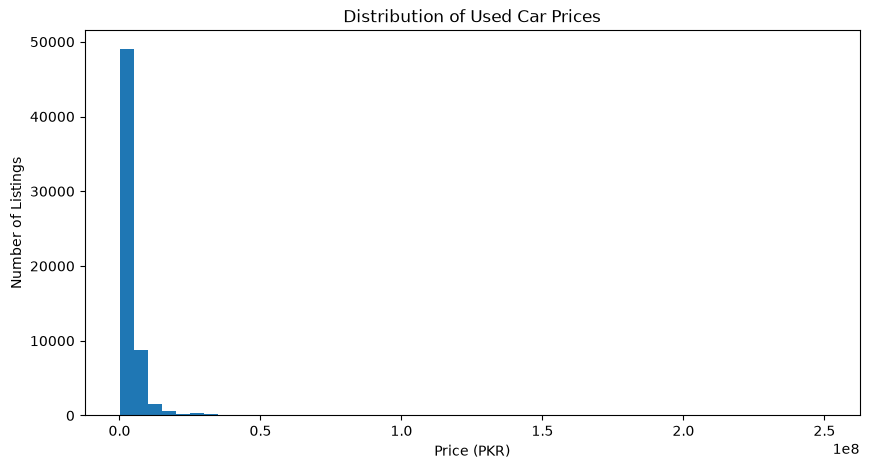

In [2]:
plt.figure(figsize=(10, 5))

plt.hist(df["price_pkr"], bins=50)

plt.title("Distribution of Used Car Prices")
plt.xlabel("Price (PKR)")
plt.ylabel("Number of Listings")

plt.show()

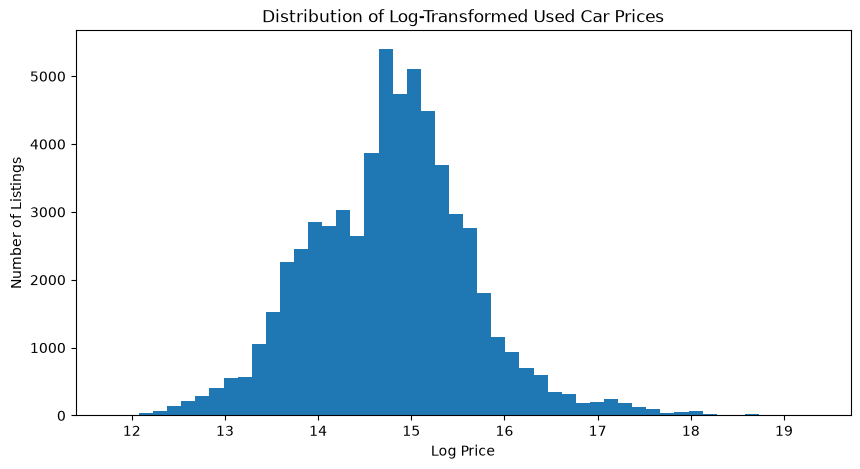

In [3]:
df["log_price"] = np.log1p(df["price_pkr"])

plt.figure(figsize=(10, 5))

plt.hist(df["log_price"], bins=50)

plt.title("Distribution of Log-Transformed Used Car Prices")
plt.xlabel("Log Price")
plt.ylabel("Number of Listings")

plt.show()

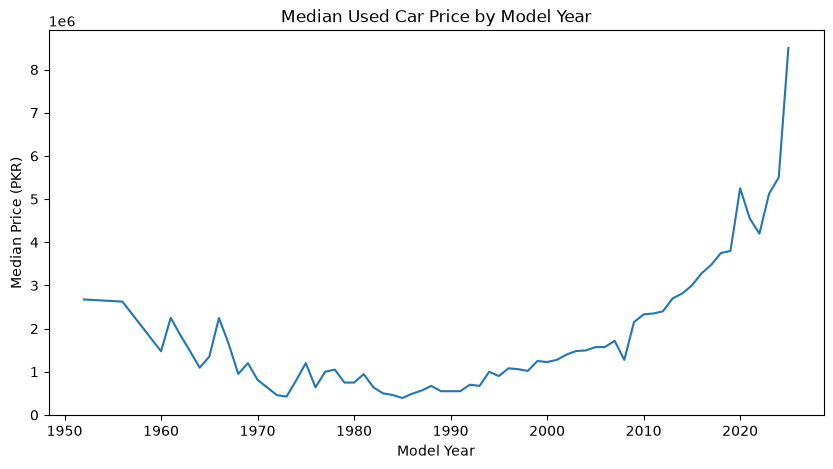

In [4]:
year_price = (
    df.groupby("year")["price_pkr"]
    .median()
    .reset_index()
)

plt.figure(figsize=(10, 5))

plt.plot(year_price["year"], year_price["price_pkr"])

plt.title("Median Used Car Price by Model Year")
plt.xlabel("Model Year")
plt.ylabel("Median Price (PKR)")

plt.show()

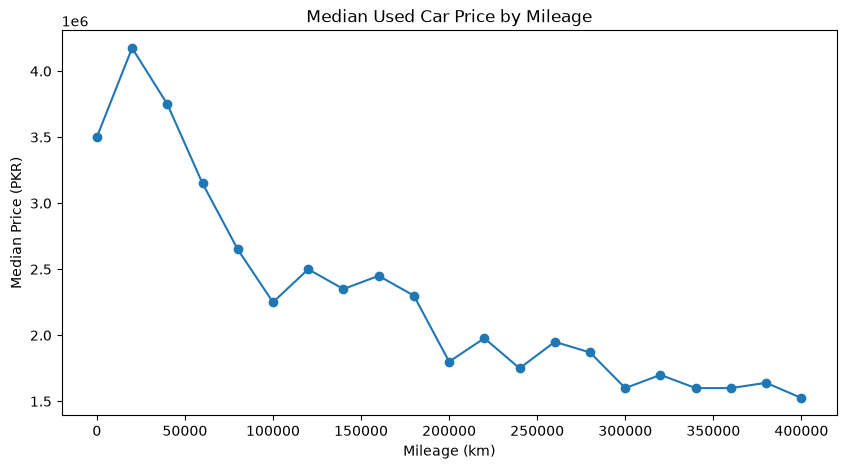

In [5]:
mileage_analysis = df.dropna(subset=["mileage_km"]).copy()

mileage_analysis["mileage_bin"] = (
    mileage_analysis["mileage_km"] // 20_000
) * 20_000

mileage_price = (
    mileage_analysis[
        mileage_analysis["mileage_km"] <= 400_000
    ]
    .groupby("mileage_bin")["price_pkr"]
    .median()
    .reset_index()
)

plt.figure(figsize=(10, 5))

plt.plot(
    mileage_price["mileage_bin"],
    mileage_price["price_pkr"],
    marker="o"
)

plt.title("Median Used Car Price by Mileage")
plt.xlabel("Mileage (km)")
plt.ylabel("Median Price (PKR)")

plt.show()

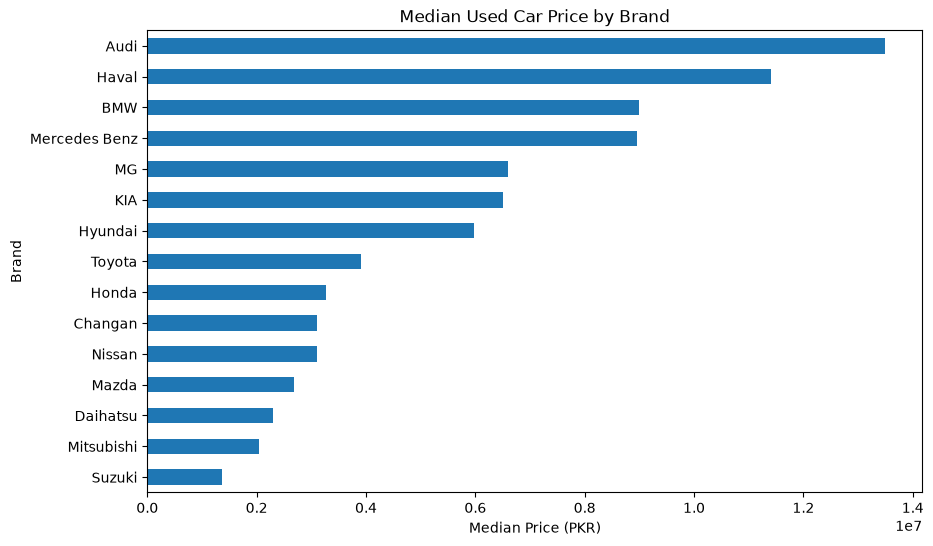

In [6]:
top_brands = df["brand"].value_counts().head(15).index

brand_price = (
    df[df["brand"].isin(top_brands)]
    .groupby("brand")["price_pkr"]
    .median()
    .sort_values()
)

plt.figure(figsize=(10, 6))

brand_price.plot(kind="barh")

plt.title("Median Used Car Price by Brand")
plt.xlabel("Median Price (PKR)")
plt.ylabel("Brand")

plt.show()

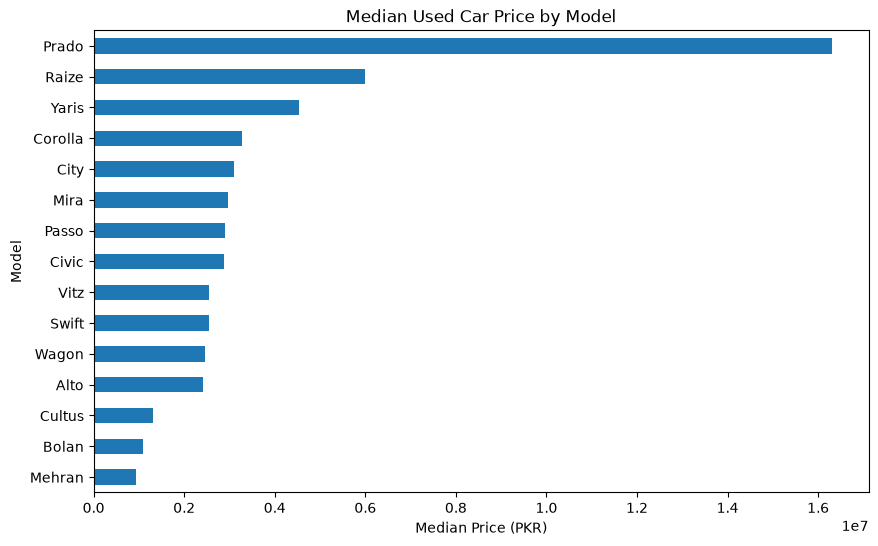

In [7]:
top_models = df["model"].value_counts().head(15).index

model_price = (
    df[df["model"].isin(top_models)]
    .groupby("model")["price_pkr"]
    .median()
    .sort_values()
)

plt.figure(figsize=(10, 6))

model_price.plot(kind="barh")

plt.title("Median Used Car Price by Model")
plt.xlabel("Median Price (PKR)")
plt.ylabel("Model")

plt.show()

transmission
Manual       1420000.0
Automatic    4000000.0
Name: price_pkr, dtype: float64


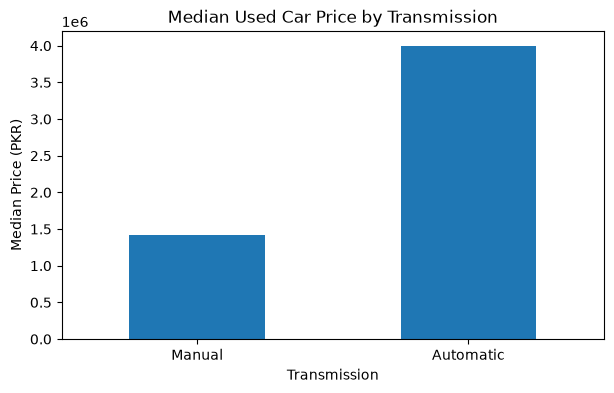

In [8]:
transmission_price = (
    df.groupby("transmission")["price_pkr"]
    .median()
    .sort_values()
)

print(transmission_price)

plt.figure(figsize=(7, 4))

transmission_price.plot(kind="bar")

plt.title("Median Used Car Price by Transmission")
plt.xlabel("Transmission")
plt.ylabel("Median Price (PKR)")
plt.xticks(rotation=0)

plt.show()

assembly
Local       2380000.0
Imported    3450000.0
Name: price_pkr, dtype: float64


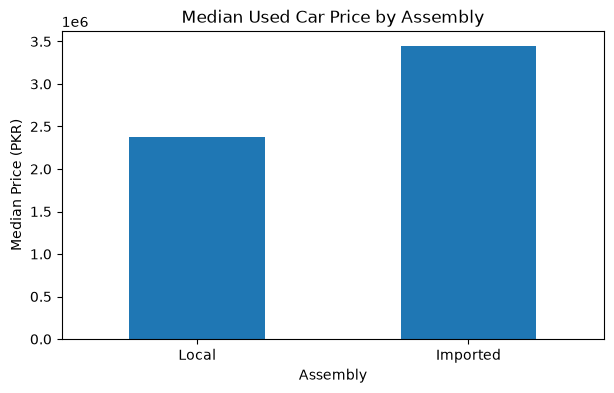

In [9]:
assembly_price = (
    df.groupby("assembly")["price_pkr"]
    .median()
    .sort_values()
)

print(assembly_price)

plt.figure(figsize=(7, 4))

assembly_price.plot(kind="bar")

plt.title("Median Used Car Price by Assembly")
plt.xlabel("Assembly")
plt.ylabel("Median Price (PKR)")
plt.xticks(rotation=0)

plt.show()